# Baseline CNN Classifier — Pneumonia vs Healthy

Train `SimpleCNN` on NIH Chest X-ray dataset **without** data augmentation.  
Uses `pos_weight` on `BCEWithLogitsLoss` to deal with unbalanced classes.

**Reported metrics:** Accuracy and AUC-ROC on test dataset.

## 1. Setup

In [1]:
import sys
import os
import json
from pathlib import Path

# Add utils and models to path
project_root = Path("../").resolve()
sys.path.insert(0, str(project_root / "utils"))
sys.path.insert(0, str(project_root / "models"))

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from preprocessing import Preprocessing
from classifier import SimpleCNN
from device import DEVICE
from metrics import print_metrics, plot_roc_curve

print(f"Device: {DEVICE}")

/Users/mabosco/Desktop/mestrado/IA376N/dgm-2026.1/projects/ecgpcx-ray/env/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Device: mps


## 2. Hyperparameters

In [2]:
IMG_SIZE    = (128, 128)
BATCH_SIZE  = 64
LR          = 3e-4
NUM_EPOCHS  = 20
DROPOUT     = 0.3
SEED        = 42

CHECKPOINT_PATH = project_root / "models" / "best_classifier.pt"
RESULTS_DIR     = project_root / "results"
RESULTS_DIR.mkdir(exist_ok=True)

## 3. Load Dataset

In [ ]:
# prep = Preprocessing(label='Pneumonia')

Resuming download from 23315087360 bytes (21781062871 bytes left)...
Resuming download from https://www.kaggle.com/api/v1/datasets/download/nih-chest-xrays/data?dataset_version_number=3 (23315087360/45096150231) bytes left.


100%|██████████| 42.0G/42.0G [11:00<00:00, 33.0MB/s]  

Extracting files...


In [ ]:
# train_dataset, test_dataset, val_dataset = prep.create_cvae_dataset(
#     img_size=IMG_SIZE,
#     train_ratio=0.7,
#     val_ratio=0.15,
#     test_ratio=0.15,
#     seed=SEED,
#     verbose=True,
# )
# 
# print(f"\nTrain: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Creating CVAE dataset...
Loading images...
Pneumonia patient records:
Number of duplicated rows: 0
Removed 0 outliers based on Patient Age.
New shape of dataframe: (322, 11)
Age normalized using Min-Max scaling. Range: [3, 87] -> [0, 1]
Healthy patient records:
Number of duplicated rows: 0
Removed 8 outliers based on Patient Age.
New shape of dataframe: (60353, 11)
Age normalized using Min-Max scaling. Range: [1, 95] -> [0, 1]
Total unique patients: 24946

--- Split Statistics (Patient-Level) ---
Seed: 42 (for reproducibility)

TRAIN set:
  Patients: 17462
  Total images: 42452
  Pneumonia: 223 images
  Healthy: 42229 images
  Ratio: 70.0%

VAL set:
  Patients: 3741
  Total images: 8798
  Pneumonia: 49 images
  Healthy: 8749 images
  Ratio: 14.5%

TEST set:
  Patients: 3743
  Total images: 9425
  Pneumonia: 50 images
  Healthy: 9375 images
  Ratio: 15.5%
Loaded 42452 images.
Loaded 8798 images.
Loaded 9425 images.

Train: 42452 | Val: 8798 | Test: 9425


In [ ]:
# import torch
# from pathlib import Path
# 
# DATA_CACHE_DIR = project_root / "data" / "processed"
# DATA_CACHE_DIR.mkdir(parents=True, exist_ok=True)
# 
# torch.save(train_dataset, DATA_CACHE_DIR / "train_dataset.pt")
# torch.save(val_dataset,   DATA_CACHE_DIR / "val_dataset.pt")
# torch.save(test_dataset,  DATA_CACHE_DIR / "test_dataset.pt")
# 
# print(f"Datasets salvos em {DATA_CACHE_DIR}")

Datasets salvos em /Users/mabosco/Desktop/mestrado/IA376N/dgm-2026.1/projects/ecgpcx-ray/data/processed


In [3]:
# Para carregar os datasets posteriormente:
DATA_CACHE_DIR = project_root / "data" / "processed"
train_dataset = torch.load(DATA_CACHE_DIR / "train_dataset.pt", weights_only=False)
val_dataset   = torch.load(DATA_CACHE_DIR / "val_dataset.pt", weights_only=False)
test_dataset  = torch.load(DATA_CACHE_DIR / "test_dataset.pt", weights_only=False)

In [4]:
# Compute pos_weight = num_healthy / num_pneumonia in the training set
train_labels = train_dataset.labels[:, 1]  # index 1 = pneumonia
n_pos = train_labels.sum().item()
n_neg = len(train_labels) - n_pos
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(DEVICE)

print(f"Train — Healthy: {int(n_neg)} | Pneumonia: {int(n_pos)}")
print(f"pos_weight: {pos_weight.item():.2f}")

Train — Healthy: 42229 | Pneumonia: 223
pos_weight: 189.37


In [5]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

## 4. Model, Loss, Optimizer

In [6]:
torch.manual_seed(SEED)

model     = SimpleCNN(dropout_rate=DROPOUT).to(DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(DEVICE)).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(   
    optimizer, mode='max', factor=0.5, patience=3
)

print(model)

SimpleCNN(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (2): ConvBlock(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
     

## 5. Training Loop

In [7]:
def run_epoch(loader, model, criterion, optimizer=None, device=DEVICE):
    """Run one epoch. If optimizer is None, runs in eval mode."""
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss = 0.0
    all_labels, all_scores = [], []

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for images, labels, _ in loader:
            images = images.to(device)                        # (B, 1, H, W)
            y = labels[:, 1].unsqueeze(1).float().to(device)  # pneumonia score

            logits = model(images)                            # (B, 1)
            loss = criterion(logits, y)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            all_labels.extend(y.cpu().squeeze(1).tolist())
            all_scores.extend(torch.sigmoid(logits).cpu().squeeze(1).tolist())

    avg_loss = total_loss / len(loader.dataset)
    return avg_loss, np.array(all_labels), np.array(all_scores)

In [8]:
from metrics import compute_roc_auc
from tqdm.notebook import tqdm
import time

best_val_auc = 0.0
history = {"train_loss": [],"train_auc": [], "val_loss": [], "val_auc": []}

pbar = tqdm(range(1, NUM_EPOCHS + 1), desc="Training", unit="epoch")
for epoch in pbar:
    start_time = time.time()
    train_loss, train_y, train_sc = run_epoch(train_loader, model, criterion, optimizer)
    val_loss, val_y, val_sc   = run_epoch(val_loader,   model, criterion)
    train_auc = compute_roc_auc(train_y, train_sc)
    val_auc = compute_roc_auc(val_y, val_sc)
    scheduler.step(val_auc) 

    history["train_loss"].append(train_loss)
    history["train_auc"].append(train_auc)
    history["val_loss"].append(val_loss)
    history["val_auc"].append(val_auc)

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        flag = " ← best"
    else:
        flag = ""

    elapsed_time = time.time() - start_time
    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} "
          f"| elapsed_time={elapsed_time:.2f}s"
          f"| train_loss={train_loss:.4f} "
          f"| train_auc={train_auc:.4f} "
          f"| val_loss={val_loss:.4f} "
          f"| val_auc={val_auc:.4f}{flag} "
          )

print(f"\nBest val AUC: {best_val_auc:.4f}")

Training:   0%|          | 0/20 [00:00<?, ?epoch/s]

Epoch 01/20 | elapsed_time=101.29s| train_loss=1.3810 | train_auc=0.5515 | val_loss=1.4378 | val_auc=0.5301 ← best 
Epoch 02/20 | elapsed_time=101.20s| train_loss=1.3568 | train_auc=0.5931 | val_loss=1.4474 | val_auc=0.5466 ← best 
Epoch 03/20 | elapsed_time=99.44s| train_loss=1.3449 | train_auc=0.6095 | val_loss=1.4440 | val_auc=0.5438 
Epoch 04/20 | elapsed_time=99.19s| train_loss=1.3396 | train_auc=0.6214 | val_loss=1.4092 | val_auc=0.5758 ← best 
Epoch 05/20 | elapsed_time=98.72s| train_loss=1.3366 | train_auc=0.6170 | val_loss=1.4183 | val_auc=0.5712 
Epoch 06/20 | elapsed_time=99.84s| train_loss=1.3298 | train_auc=0.6275 | val_loss=1.4941 | val_auc=0.5703 
Epoch 07/20 | elapsed_time=101.61s| train_loss=1.3116 | train_auc=0.6498 | val_loss=1.4244 | val_auc=0.5747 
Epoch 08/20 | elapsed_time=100.36s| train_loss=1.3206 | train_auc=0.6349 | val_loss=1.4266 | val_auc=0.5790 ← best 
Epoch 09/20 | elapsed_time=101.22s| train_loss=1.3051 | train_auc=0.6593 | val_loss=1.4215 | val_auc=0.5

## 6. Training Curves

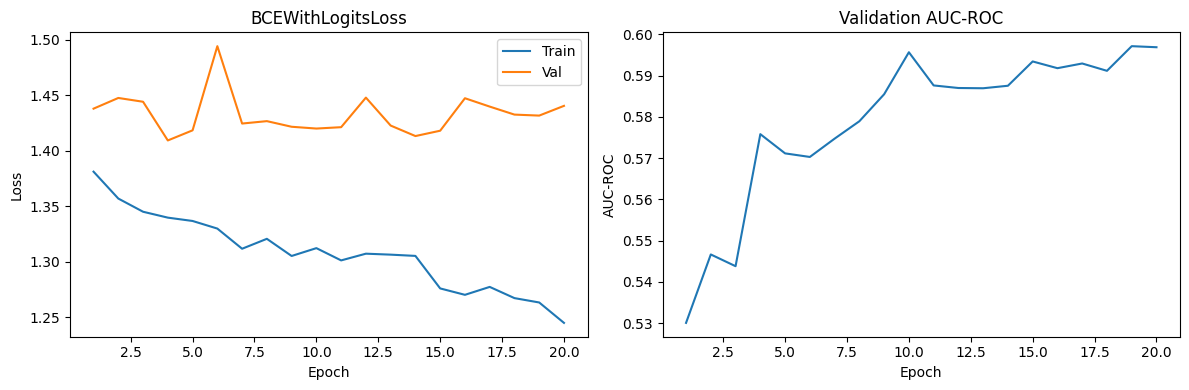

In [9]:
import matplotlib.pyplot as plt

epochs = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history["train_loss"], label="Train")
axes[0].plot(epochs, history["val_loss"],   label="Val")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("BCEWithLogitsLoss")
axes[0].legend()

axes[1].plot(epochs, history["val_auc"])
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("AUC-ROC")
axes[1].set_title("Validation AUC-ROC")

fig.tight_layout()
fig.savefig(RESULTS_DIR / "training_curves.png", dpi=150)
plt.show()

## 7. Evaluation on Test Set

In [10]:
# Load best checkpoint
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))

_, test_y, test_scores = run_epoch(test_loader, model, criterion)

print("=== Test Set Metrics ===")
print_metrics(test_y, test_scores)

=== Test Set Metrics ===
Accuracy : 0.6135
AUC-ROC  : 0.6284
Confusion matrix (threshold=0.5):
  TN=5752  FP=3623
  FN=20  TP=30


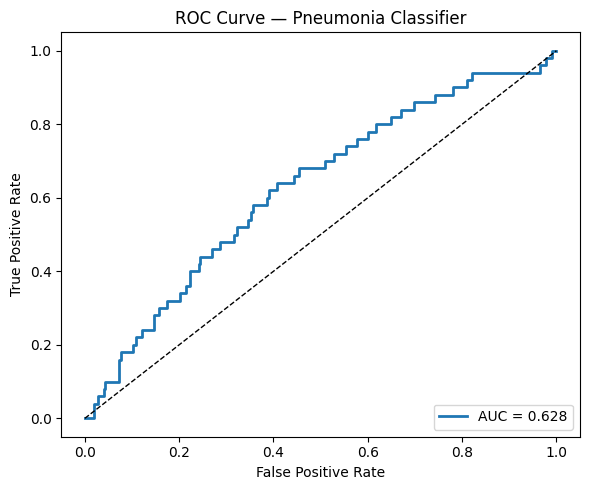

In [11]:
fig = plot_roc_curve(test_y, test_scores, save_path=RESULTS_DIR / "roc_curve.png")
plt.show()

## 8. Save Results

In [12]:
from metrics import compute_accuracy, compute_roc_auc

results = {
    "model": "SimpleCNN",
    "img_size": list(IMG_SIZE),
    "epochs": NUM_EPOCHS,
    "batch_size": BATCH_SIZE,
    "lr": LR,
    "dropout": DROPOUT,
    "seed": SEED,
    "pos_weight": round(pos_weight.item(), 4),
    "best_val_auc": round(best_val_auc, 4),
    "test_accuracy": round(compute_accuracy(test_y, test_scores), 4),
    "test_auc_roc":  round(compute_roc_auc(test_y, test_scores), 4),
    "history": history,
}

results_path = RESULTS_DIR / "baseline_results.json"
with open(results_path, "w") as f:
    json.dump(results, f, indent=2)

print(f"Results saved to {results_path}")
print(json.dumps({k: v for k, v in results.items() if k != 'history'}, indent=2))

Results saved to /Users/mabosco/Desktop/mestrado/IA376N/dgm-2026.1/projects/ecgpcx-ray/results/baseline_results.json
{
  "model": "SimpleCNN",
  "img_size": [
    128,
    128
  ],
  "epochs": 20,
  "batch_size": 64,
  "lr": 0.0003,
  "dropout": 0.3,
  "seed": 42,
  "pos_weight": 189.3677,
  "best_val_auc": 0.5972,
  "test_accuracy": 0.6135,
  "test_auc_roc": 0.6284
}
